## 📚 Import Required Libraries

In this section, we import the essential Python libraries required for data processing, visualization, image handling, and model development.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings
warnings.filterwarnings('ignore')

import glob as gb
from tqdm import tqdm
import cv2

import tensorflow
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.models import Sequential


## 📥 Download Dataset

Download the dataset from Kaggle using KaggleHub and get the dataset path for further processing.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akshitmadan/eyes-open-or-closed")

print("Path to dataset files:", path)

100%|██████████| 22.6M/22.6M [00:02<00:00, 11.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/akshitmadan/eyes-open-or-closed/versions/1


In [3]:
os.listdir(path)

['dataset']

In [4]:
os.listdir(path+'/dataset')

['train', 'test']

## 📂 Define Dataset Paths

Set the paths for the training and testing image directories.

In [5]:
train_dir = path+'/dataset/train'
test_dir = path+'/dataset/test'

In [6]:
os.listdir(train_dir)

['Closed_Eyes', 'Open_Eyes']

In [7]:
os.listdir(test_dir)

['Closed_Eyes', 'Open_Eyes']

## 🖼️ Visualize Sample Images

Display sample images from each class to understand the dataset distribution.

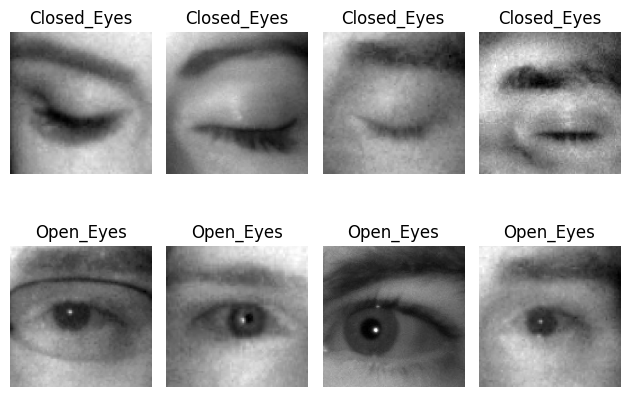

In [8]:
# show some sample of data first row 4 img of class one and second is 4 img in anther class

c =1
for folder in os.listdir(train_dir):
    #['Closed_Eyes', 'Open_Eyes']
    files = gb.glob(os.path.join(train_dir,folder,'*.png'))
    for file in files[:4]:
        img =cv2.imread(file)
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
        plt.subplot(2,4,c)
        plt.imshow(img,cmap='gray')
        plt.axis('off')
        plt.title(f"{folder}")
        sample = img

        c+=1

plt.tight_layout()
plt.show()


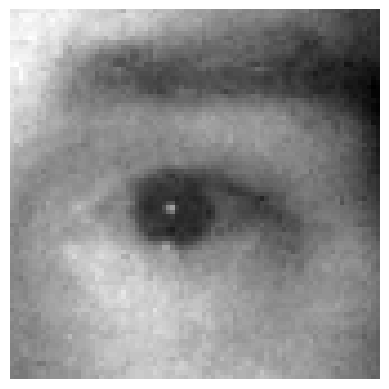

In [9]:
plt.imshow(sample,cmap='gray')
plt.axis('off')
plt.show()

In [10]:
sample.shape

(83, 83)

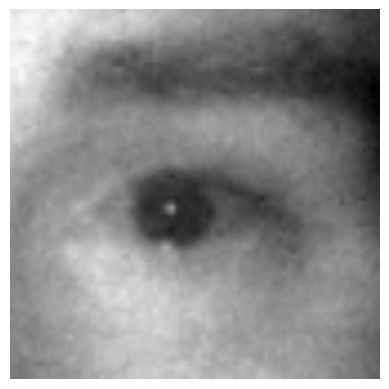

(224, 224)

In [11]:
sample2 = cv2.resize(sample,(224,224))

plt.imshow(sample2,cmap='gray')
plt.axis('off')
plt.show()
sample2.shape

## 🔄 Load and Preprocess Images

Read images, resize them to a fixed size, normalize pixel values, and store images with their corresponding labels.

In [12]:
x_Train = []
y_Train = []
img_H = 224
img_W = 224

for folder in os.listdir(train_dir):
    print(f"Folder is {folder}")

    # Read img & store it
    for file in tqdm(gb.glob(train_dir+'/'+folder+'/*.png')):
        img = cv2.imread(file)
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img,(img_H,img_W))
        img = img/255.0
        x_Train.append(img)
        y_Train.append(folder)

Folder is Closed_Eyes


100%|██████████| 1760/1760 [00:00<00:00, 1941.01it/s]


Folder is Open_Eyes


100%|██████████| 1640/1640 [00:00<00:00, 1983.70it/s]


## 🔢 Convert Images to NumPy Array

Convert the image list into a NumPy array and reshape it to match the input format required for the CNN model.

In [13]:
x_Train = np.array(x_Train)
x_Train = x_Train.reshape(x_Train.shape[0],x_Train.shape[1],x_Train.shape[2],1)
x_Train.shape

(3400, 224, 224, 1)

In [14]:
y_Train = np.array(y_Train)
y_Train.shape

(3400,)

## 🖼️ Display Random Samples

Visualize random images from the training set along with their corresponding labels.

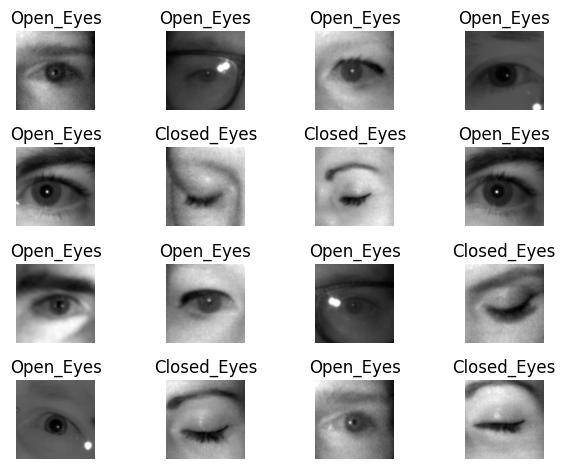

In [15]:
# Show sample from x_train
for index , img in enumerate(np.random.randint(0,len(x_Train),16)):
    plt.subplot(4,4,index+1)
    plt.imshow(x_Train[img],cmap='gray')
    plt.title(y_Train[img])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 🧪 Load and Preprocess Test Images

Read test images, resize, normalize pixel values, and store them with their corresponding labels.

In [16]:
x_test = []
y_test = []

for folder in os.listdir(test_dir):
    print('Now Folder is ',folder)

    for file in tqdm(gb.glob(train_dir+'/'+folder+'/*.png')):
        img = cv2.imread(file)
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img,(img_H,img_W))
        img = img/255.0

        x_test.append(img)
        y_test.append(folder)

Now Folder is  Closed_Eyes


100%|██████████| 1760/1760 [00:00<00:00, 2046.16it/s]


Now Folder is  Open_Eyes


100%|██████████| 1640/1640 [00:00<00:00, 2042.19it/s]


## 🔢 Convert Test Data to NumPy Arrays

Convert test images and labels into NumPy arrays and reshape images for model input.

In [17]:
x_test = np.array(x_test)
x_test = x_test.reshape(x_test.shape[0],x_test.shape[1],x_test.shape[2],1)

y_test = np.array(y_test)

print('Shape of x_test = ',x_test.shape)
print('Shape of y_test = ',y_test.shape)

Shape of x_test =  (3400, 224, 224, 1)
Shape of y_test =  (3400,)


## 🖼️ Display Test Samples

Visualize random images from the test set with their corresponding labels.

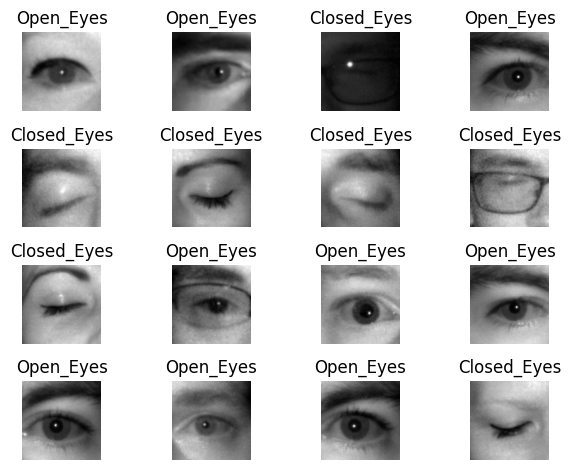

In [18]:
# Sample from test sample
np.random.seed(0)
for index ,img in enumerate(np.random.randint(0,len(x_test),16)):
    plt.subplot(4,4,index+1)
    plt.imshow(x_test[img],cmap='gray')
    plt.title(y_test[img])
    plt.axis('off')

plt.tight_layout()
plt.show()

## 🔀 Shuffle Dataset

Shuffle the training and testing data to ensure a random distribution of samples before training the model.

In [19]:
from sklearn.utils import shuffle

x_train ,y_train = shuffle(x_Train,y_Train)
x_test , y_test = shuffle(x_test,y_test)

## 📊 Class Distribution

Visualize the number of samples in each class to check the dataset balance (Train & Test data).

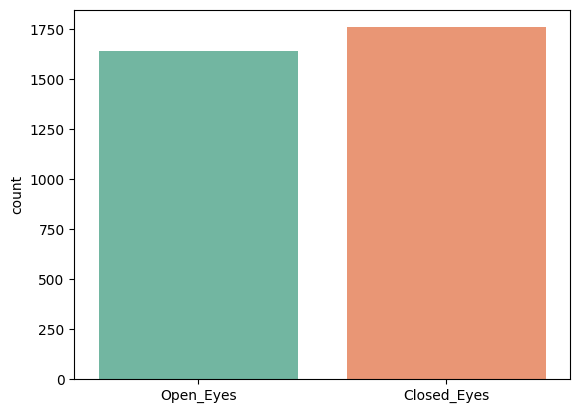

In [20]:
sns.countplot(x=y_train,palette='Set2')
plt.show()

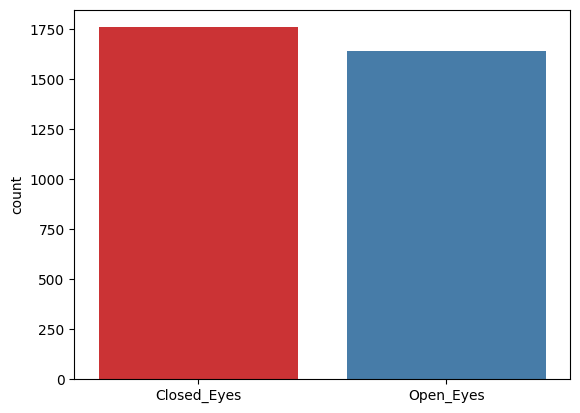

In [21]:
# show data in y_test
sns.countplot(x=y_test,palette='Set1')
plt.show()

## 🔢 Encode Labels

Apply Label Encoding to convert class labels into numerical values for model training.

In [22]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
y_train = LE.fit_transform(y_train)
y_test = LE.transform(y_test)

In [23]:
y_train


array([1, 0, 0, ..., 1, 1, 1])

In [24]:
y_test

array([0, 1, 1, ..., 1, 1, 1])

## 🧠 Build CNN Model

Create a Convolutional Neural Network (CNN) architecture for image classification using convolution, pooling, and dense layers.

In [30]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=64,kernel_size=7,strides=1,activation='relu',input_shape=(img_H,img_H,1)),
    keras.layers.MaxPool2D(pool_size=2),

    keras.layers.Conv2D(128,5,1,activation='relu'),
    keras.layers.MaxPool2D(pool_size=2),

    keras.layers.Conv2D(256,3,1,activation='relu'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 218, 218, 64)   │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 105, 105, 128)  │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 160000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    20,480,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,991,745 (80.08 MB)

 Trainable params: 20,991,745 (80.08 MB)

 Non-trainable params: 0 (0.00 B)

## ⚙️ Compile Model

Configure the CNN model using the loss function, optimizer, and evaluation metric required for training.

In [32]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

## 🚀 Train CNN Model

Train the CNN model on the training data and monitor its performance using a validation split.

In [33]:
history = model.fit(x_train,y_train,epochs=15,batch_size=100,validation_split=0.1)

Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 467ms/step - accuracy: 0.6984 - loss: 0.5723 - val_accuracy: 0.9382 - val_loss: 0.2558
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 375ms/step - accuracy: 0.9500 - loss: 0.1804 - val_accuracy: 0.9588 - val_loss: 0.1140
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 375ms/step - accuracy: 0.9673 - loss: 0.1049 - val_accuracy: 0.9794 - val_loss: 0.0814
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 375ms/step - accuracy: 0.9739 - loss: 0.0889 - val_accuracy: 0.9471 - val_loss: 0.1172
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.9879 - loss: 0.0369 - val_accuracy: 0.9765 - val_loss: 0.0687
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.9931 - loss: 0.0249 - val_accuracy: 0.9853 - val_loss: 0.0499
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.9922 - loss: 0.0199 - val_accuracy: 0.9706 - val_loss: 0.0943
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 374ms/step - accuracy: 0.9778 - loss: 0.0898 - val_accu

In [34]:
epoch = len(history.history['loss'] )
epoch

15

## 📉 Training and Validation Loss

Plot the training and validation loss over epochs to evaluate the model learning process.

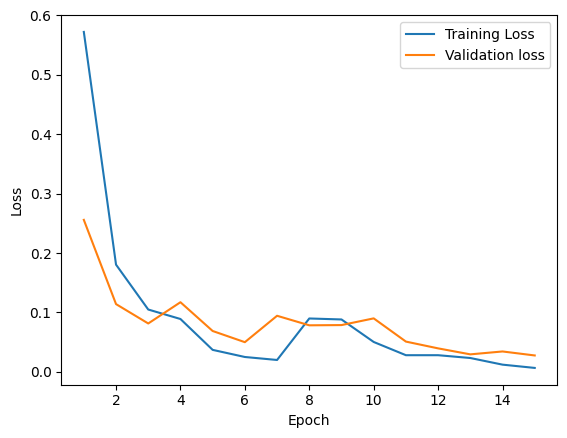

In [35]:
plt.plot(range(1,epoch+1),history.history['loss'],label='Training Loss')
plt.plot(range(1,epoch+1),history.history['val_loss'],label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## 📈 Training and Validation Accuracy

Plot the training and validation accuracy over epochs to evaluate the model performance.

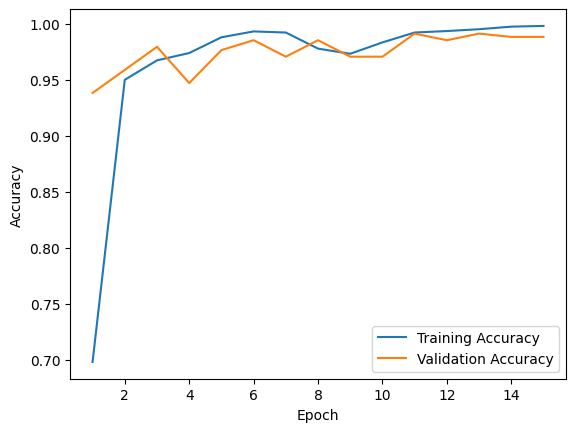

In [37]:
plt.plot(range(1,epoch+1),history.history['accuracy'],label = 'Training Accuracy')
plt.plot(range(1,epoch+1),history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## 🧪 Evaluate Model Performance

Evaluate the trained model on the test and training datasets to measure its loss and accuracy.

In [38]:
model.evaluate(x_train,y_train)

107/107 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9979 - loss: 0.0061


[0.006051008123904467, 0.9979411959648132]

In [39]:
model.evaluate(x_test,y_test)

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9979 - loss: 0.0061


[0.006051008589565754, 0.9979411959648132]

## 🔮 Make Predictions

Use the trained model to predict the classes of the test images.

In [40]:
y_pred = model.predict(x_test)

107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step


## 🔢 Convert Predictions

Round the model predictions to convert probability outputs into binary class labels.

In [41]:
y_pred[:4]

array([[2.5427744e-05],
       [9.9961376e-01],
       [9.9890900e-01],
       [9.9991941e-01]], dtype=float32)

In [42]:
y_pred = y_pred.round()
y_pred[:5]

array([[0.],
       [1.],
       [1.],
       [1.],
       [0.]], dtype=float32)

## 📊 Model Evaluation Metrics

Generate the confusion matrix and classification report to evaluate the model performance using different classification metrics.

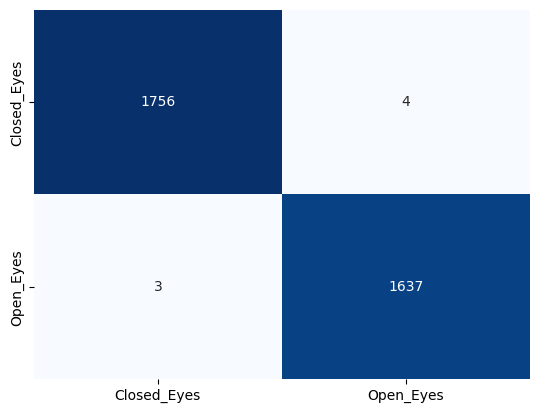

In [50]:
from sklearn.metrics import  confusion_matrix ,classification_report
conf = confusion_matrix(y_test,y_pred)

sns.heatmap(conf,annot=True,fmt='d',cmap='Blues',cbar=False,xticklabels=LE.classes_,yticklabels=LE.classes_)
plt.show()

In [51]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1760
           1       1.00      1.00      1.00      1640

    accuracy                           1.00      3400
   macro avg       1.00      1.00      1.00      3400
weighted avg       1.00      1.00      1.00      3400



In [53]:
model.save("eye_classifier.keras")

In [54]:
import pickle

with open("label_encoder.pkl","wb") as f:
    pickle.dump(LE,f)

In [56]:
from google.colab import files

files.download('/content/eye_classifier.keras')
files.download('/content/label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>